In [1]:
import pandas as pd
import numpy as np
from scipy.io import loadmat

In [2]:
def extract_battery_data(file_path, battery_id):

    mat = loadmat(file_path)

    battery = mat[battery_id]

    cycle = battery["cycle"][0,0]

    rows = []

    discharge_count = 0

    for i in range(cycle.shape[1]):

        if cycle["type"][0,i][0] == "discharge":

            discharge_count += 1

            data = cycle["data"][0,i]

            capacity = float(
                data["Capacity"][0,0][0,0]
            )

            avg_voltage = np.mean(
                data["Voltage_measured"][0,0]
            )

            avg_current = np.mean(
                data["Current_measured"][0,0]
            )

            avg_temp = np.mean(
                data["Temperature_measured"][0,0]
            )

            rows.append([
                battery_id,
                discharge_count,
                capacity,
                avg_voltage,
                avg_current,
                avg_temp
            ])

    df = pd.DataFrame(
        rows,
        columns=[
            "Battery_ID",
            "Cycle",
            "Capacity",
            "AvgVoltage",
            "AvgCurrent",
            "AvgTemp"
        ]
    )

    initial_capacity = df["Capacity"].iloc[0]

    df["SOH"] = (
        df["Capacity"]
        /
        initial_capacity
    ) * 100

    return df

In [3]:
b0005 = extract_battery_data(
    "../data/raw/B0005.mat",
    "B0005"
)

b0006 = extract_battery_data(
    "../data/raw/B0006.mat",
    "B0006"
)

b0007 = extract_battery_data(
    "../data/raw/B0007.mat",
    "B0007"
)

b0018 = extract_battery_data(
    "../data/raw/B0018.mat",
    "B0018"
)

In [4]:
master_df = pd.concat(
    [
        b0005,
        b0006,
        b0007,
        b0018
    ],
    ignore_index=True
)

In [5]:
print(master_df.shape)

master_df.head()

(636, 7)


,Battery_ID,Cycle,Capacity,AvgVoltage,AvgCurrent,AvgTemp,SOH
0,B0005,1,1.856487,3.529829,-1.818702,32.572328,100.000000
1,B0005,2,1.846327,3.537320,-1.817560,32.725235,99.452721
2,B0005,3,1.835349,3.543737,-1.816487,32.642862,98.861386
3,B0005,4,1.835263,3.543666,-1.825589,32.514876,98.856718
4,B0005,5,1.834646,3.542343,-1.826114,32.382349,98.823482


In [7]:
master_df.shape

master_df["Battery_ID"].value_counts()

Battery_ID
B0005    168
B0006    168
B0007    168
B0018    132
Name: count, dtype: int64

In [8]:
WINDOW = 10

X = []
y = []

for battery in master_df["Battery_ID"].unique():

    temp_df = master_df[
        master_df["Battery_ID"] == battery
    ].reset_index(drop=True)

    soh_values = temp_df["SOH"].values

    for i in range(
        len(soh_values) - WINDOW
    ):

        X.append(
            soh_values[i:i+WINDOW]
        )

        y.append(
            soh_values[i+WINDOW]
        )

X = np.array(X)

y = np.array(y)

print(X.shape)
print(y.shape)

(596, 10)
(596,)


In [9]:
split = int(
    len(X) * 0.8
)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [10]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05
)

model.fit(
    X_train,
    y_train
)

preds = model.predict(X_test)

In [11]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

r2 = r2_score(
    y_test,
    preds
)

print("MAE =", mae)
print("RMSE =", rmse)
print("R² =", r2)

MAE = 0.7018478773502235
RMSE = 1.2062346028861288
R² = 0.9725752087547472


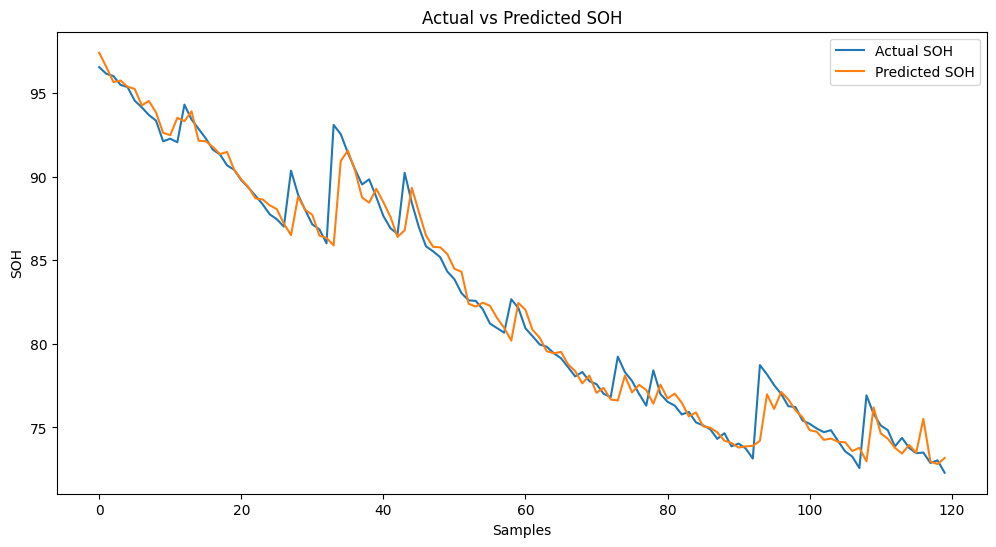

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test,
    label="Actual SOH"
)

plt.plot(
    preds,
    label="Predicted SOH"
)

plt.legend()

plt.title("Actual vs Predicted SOH")

plt.xlabel("Samples")

plt.ylabel("SOH")

plt.show()

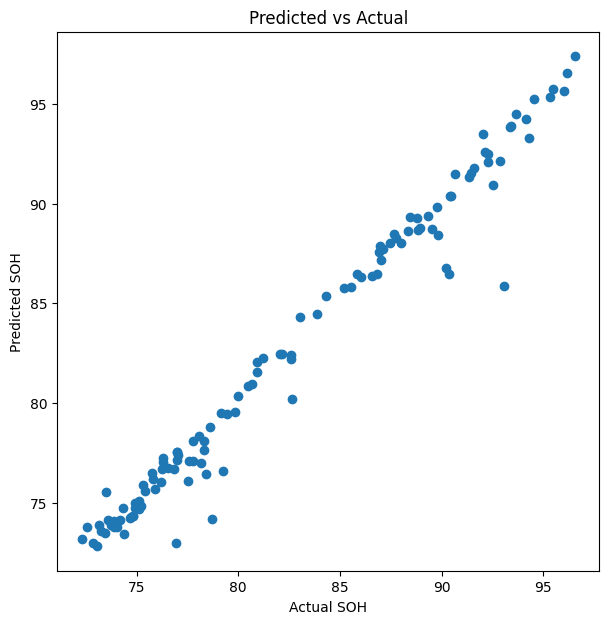

In [13]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    preds
)

plt.xlabel("Actual SOH")

plt.ylabel("Predicted SOH")

plt.title("Predicted vs Actual")

plt.show()

In [14]:
import numpy as np

def forecast_until_eol(model, current_window,
                       threshold=80,
                       max_future=200):

    window = current_window.copy()

    predictions = []

    for step in range(max_future):

        next_soh = model.predict(
            window.reshape(1, -1)
        )[0]

        predictions.append(next_soh)

        if next_soh <= threshold:
            break

        window = np.append(
            window[1:],
            next_soh
        )

    return predictions

In [15]:
battery_df = master_df[
    master_df["Battery_ID"] == "B0005"
].reset_index(drop=True)

In [16]:
current_window = (
    battery_df["SOH"]
    .values[-10:]
)

In [17]:
future_soh = forecast_until_eol(
    model,
    current_window,
    threshold=80
)

print("Predicted Future Cycles:",
      len(future_soh))

Predicted Future Cycles: 1


In [18]:
rul_cycles = len(future_soh)

print(
    "Predicted RUL:",
    rul_cycles,
    "cycles"
)

Predicted RUL: 1 cycles


In [20]:
print(current_window)
print("Current SOH =", current_window[-1])

[70.18808229 70.20555816 70.2083962  69.91090088 69.9209427  69.67263012
 69.3785144  69.34884167 70.51032771 71.37561579]
Current SOH = 71.37561578838873


In [21]:
test_cycle = 100

current_window = (
    battery_df["SOH"]
    .values[test_cycle-10:test_cycle]
)

print("Current SOH =", current_window[-1])

future_soh = forecast_until_eol(
    model,
    current_window,
    threshold=80
)

print("Predicted RUL =", len(future_soh))
print(future_soh[:10])

Current SOH = 80.03654470798278
Predicted RUL = 1
[np.float32(79.63205)]


In [22]:
features = [
    "SOH",
    "Capacity",
    "AvgVoltage",
    "AvgCurrent",
    "AvgTemp"
]

WINDOW = 10

X = []
y = []

for battery in master_df["Battery_ID"].unique():

    temp_df = master_df[
        master_df["Battery_ID"] == battery
    ].reset_index(drop=True)

    data = temp_df[features].values

    soh_target = temp_df["SOH"].values

    for i in range(len(temp_df) - WINDOW):

        X.append(
            data[i:i+WINDOW]
        )

        y.append(
            soh_target[i+WINDOW]
        )

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(596, 10, 5)
(596,)


In [23]:
features = [
    "SOH",
    "Capacity",
    "AvgVoltage",
    "AvgCurrent",
    "AvgTemp"
]

WINDOW = 10

X = []
y = []

for battery in master_df["Battery_ID"].unique():

    temp_df = master_df[
        master_df["Battery_ID"] == battery
    ].reset_index(drop=True)

    data = temp_df[features].values

    soh_target = temp_df["SOH"].values

    for i in range(len(temp_df) - WINDOW):

        X.append(
            data[i:i+WINDOW]
        )

        y.append(
            soh_target[i+WINDOW]
        )

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(596, 10, 5)
(596,)


In [24]:
X_flat = X.reshape(
    X.shape[0],
    X.shape[1] * X.shape[2]
)

print(X_flat.shape)

(596, 50)


In [25]:
split = int(len(X_flat) * 0.8)

X_train = X_flat[:split]
X_test = X_flat[split:]

y_train = y[:split]
y_test = y[split:]

In [26]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [27]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

preds = model.predict(X_test)

mae = mean_absolute_error(
    y_test,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

r2 = r2_score(
    y_test,
    preds
)

print("MAE =", mae)
print("RMSE =", rmse)
print("R² =", r2)

MAE = 0.9609604782438544
RMSE = 1.4413603370558248
R² = 0.960841603542345


In [28]:
from scipy.io import loadmat

mat = loadmat("../data/raw/B0005.mat")

battery = mat["B0005"]

cycle = battery["cycle"][0,0]

for i in range(cycle.shape[1]):

    if cycle["type"][0,i][0] == "impedance":

        print("Impedance Index:", i)

        imp_data = cycle["data"][0,i]

        print(imp_data.dtype)

        break

Impedance Index: 40
[('Sense_current', 'O'), ('Battery_current', 'O'), ('Current_ratio', 'O'), ('Battery_impedance', 'O'), ('Rectified_Impedance', 'O'), ('Re', 'O'), ('Rct', 'O')]


In [29]:
print("Re =",
      imp_data["Re"][0,0][0,0])

print("Rct =",
      imp_data["Rct"][0,0][0,0])

Re = 0.04466870036616091
Rct = 0.06945627304536996


In [30]:
def extract_impedance_data(file_path, battery_id):

    mat = loadmat(file_path)

    battery = mat[battery_id]

    cycle = battery["cycle"][0,0]

    rows = []

    imp_count = 0

    for i in range(cycle.shape[1]):

        if cycle["type"][0,i][0] == "impedance":

            imp_count += 1

            data = cycle["data"][0,i]

            re = float(
                data["Re"][0,0][0,0]
            )

            rct = float(
                data["Rct"][0,0][0,0]
            )

            rows.append([
                battery_id,
                imp_count,
                re,
                rct
            ])

    return pd.DataFrame(
        rows,
        columns=[
            "Battery_ID",
            "Impedance_Cycle",
            "Re",
            "Rct"
        ]
    )

In [31]:
imp_b0005 = extract_impedance_data(
    "../data/raw/B0005.mat",
    "B0005"
)

imp_b0006 = extract_impedance_data(
    "../data/raw/B0006.mat",
    "B0006"
)

imp_b0007 = extract_impedance_data(
    "../data/raw/B0007.mat",
    "B0007"
)

imp_b0018 = extract_impedance_data(
    "../data/raw/B0018.mat",
    "B0018"
)

In [32]:
imp_master = pd.concat(
    [
        imp_b0005,
        imp_b0006,
        imp_b0007,
        imp_b0018
    ],
    ignore_index=True
)

In [34]:
for battery in imp_master["Battery_ID"].unique():

    mask = imp_master["Battery_ID"] == battery

    max_imp = imp_master.loc[
        mask,
        "Impedance_Cycle"
    ].max()

    max_dis = master_df.loc[
        master_df["Battery_ID"] == battery,
        "Cycle"
    ].max()

    imp_master.loc[
        mask,
        "Cycle"
    ] = (
        imp_master.loc[
            mask,
            "Impedance_Cycle"
        ]
        * max_dis
        / max_imp
    ).round().astype(int)

In [35]:
imp_merge = imp_master[
    [
        "Battery_ID",
        "Cycle",
        "Re",
        "Rct"
    ]
]

In [38]:
master_df["Cycle"] = master_df["Cycle"].astype(int)

imp_merge["Cycle"] = imp_merge["Cycle"].astype(int)

C:\Users\PC\AppData\Local\Temp\ipykernel_27680\3446194318.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  imp_merge["Cycle"] = imp_merge["Cycle"].astype(int)


In [40]:
master_df_sorted = (
    master_df
    .sort_values(["Battery_ID", "Cycle"])
    .reset_index(drop=True)
)

imp_merge_sorted = (
    imp_merge
    .sort_values(["Battery_ID", "Cycle"])
    .reset_index(drop=True)
)

In [42]:
final_df = pd.merge(
    master_df,
    imp_merge,
    on=["Battery_ID", "Cycle"],
    how="left"
)

In [43]:
final_df["Re"] = (
    final_df.groupby("Battery_ID")["Re"]
    .ffill()
    .bfill()
)

final_df["Rct"] = (
    final_df.groupby("Battery_ID")["Rct"]
    .ffill()
    .bfill()
)

In [44]:
final_df.columns

Index(['Battery_ID', 'Cycle', 'Capacity', 'AvgVoltage', 'AvgCurrent',
       'AvgTemp', 'SOH', 'Re', 'Rct'],
      dtype='object')

In [45]:
import numpy as np

FEATURES = [
    "SOH",
    "Capacity",
    "AvgVoltage",
    "AvgCurrent",
    "AvgTemp",
    "Re",
    "Rct"
]

WINDOW = 10

X = []
y = []

for battery in final_df["Battery_ID"].unique():

    temp_df = (
        final_df[
            final_df["Battery_ID"] == battery
        ]
        .sort_values("Cycle")
        .reset_index(drop=True)
    )

    data = temp_df[FEATURES].values

    target = temp_df["SOH"].values

    for i in range(len(temp_df) - WINDOW):

        X.append(
            data[i:i+WINDOW]
        )

        y.append(
            target[i+WINDOW]
        )

X = np.array(X)
y = np.array(y)

print("X shape =", X.shape)
print("y shape =", y.shape)

X shape = (926, 10, 7)
y shape = (926,)


In [46]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_reshaped = X.reshape(
    -1,
    X.shape[2]
)

X_scaled = scaler.fit_transform(
    X_reshaped
)

X_scaled = X_scaled.reshape(
    X.shape
)

In [47]:
split = int(len(X_scaled) * 0.8)

X_train = X_scaled[:split]
X_test = X_scaled[split:]

y_train = y[:split]
y_test = y[split:]

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(10,7)
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    LSTM(32)
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(16, activation="relu")
)

model.add(
    Dense(1)
)

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

c:\Users\PC\OneDrive\Desktop\TATA Motors\EV_Battery_RUL_Project\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 6326.6143 - mae: 78.5845 - val_loss: 5415.7866 - val_mae: 73.5618
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5101.6079 - mae: 70.3627 - val_loss: 4389.4780 - val_mae: 66.2195
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4082.8604 - mae: 62.6151 - val_loss: 3291.4976 - val_mae: 57.3328
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2869.1001 - mae: 51.9956 - val_loss: 2086.2864 - val_mae: 45.6271
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1785.9149 - mae: 40.1461 - val_loss: 1146.4806 - val_mae: 33.7939
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1004.4319 - mae: 28.7740 - val_loss: 527.1017 - val_mae: 22.8615
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 531.3222 - mae: 19.6990 - val_loss: 199.4919 - val_mae: 13.9657
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 311.2199 - mae: 14.5659 - val_loss: 64.2183 - val_mae: 7.7309

In [51]:
preds = model.predict(X_test)

preds = preds.flatten()

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step


In [52]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

r2 = r2_score(
    y_test,
    preds
)

print("MAE =", mae)
print("RMSE =", rmse)
print("R² =", r2)

MAE = 2.1512056716901613
RMSE = 3.466477836233561
R² = 0.7407458429837572


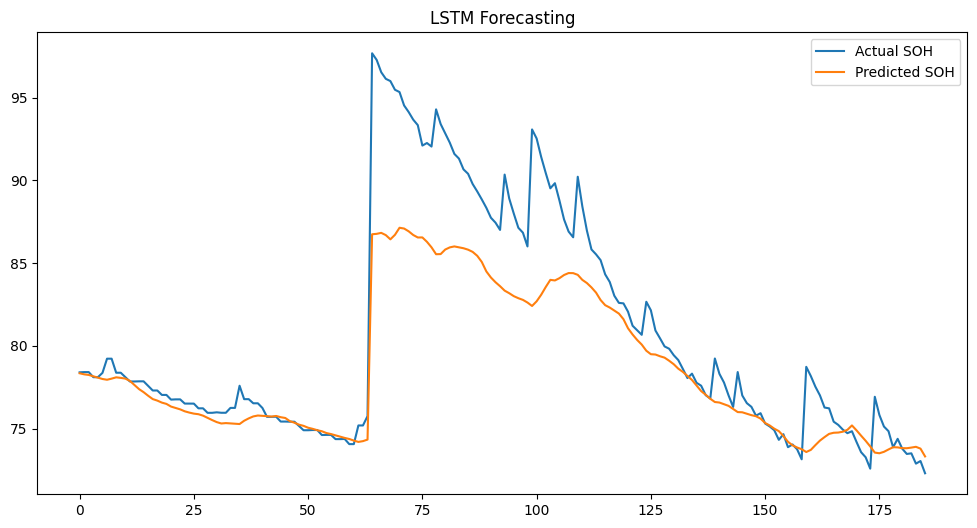

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test,
    label="Actual SOH"
)

plt.plot(
    preds,
    label="Predicted SOH"
)

plt.legend()

plt.title("LSTM Forecasting")

plt.show()

XGBoost

In [55]:
WINDOW = 10

X = []
y = []

FEATURES = [
    "Capacity",
    "AvgVoltage",
    "AvgCurrent",
    "AvgTemp",
    "Re",
    "Rct"
]

for battery in final_df["Battery_ID"].unique():

    temp = (
        final_df[
            final_df["Battery_ID"] == battery
        ]
        .sort_values("Cycle")
        .reset_index(drop=True)
    )

    values = temp[FEATURES].values

    target = temp["Capacity"].values

    for i in range(len(temp) - WINDOW):

        X.append(
            values[i:i+WINDOW].flatten()
        )

        y.append(
            target[i+WINDOW]
        )

X = np.array(X)
y = np.array(y)

print(X.shape)

(926, 60)


In [56]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [57]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [58]:
preds = model.predict(X_test)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

r2 = r2_score(
    y_test,
    preds
)

print("MAE =", mae)
print("RMSE =", rmse)
print("R² =", r2)

MAE = 0.022643661999482617
RMSE = 0.027527217077493244
R² = 0.9483189895699569


In [59]:
initial_capacity = 1.856487

pred_soh = (
    preds
    /
    initial_capacity
) * 100

In [60]:
def forecast_capacity(
    model,
    current_window,
    n_future=100
):
    window = current_window.copy()

    forecasts = []

    for _ in range(n_future):

        x = window.flatten().reshape(1, -1)

        next_capacity = model.predict(x)[0]

        forecasts.append(next_capacity)

        new_row = window[-1].copy()

        # update predicted capacity
        new_row[0] = next_capacity

        # keep other features same for now
        window = np.vstack([
            window[1:],
            new_row
        ])

    return forecasts

In [62]:
battery_df = (
    final_df[
        final_df["Battery_ID"] == "B0005"
    ]
    .sort_values("Cycle")
    .reset_index(drop=True)
)

In [63]:
current_cycle = 100

FEATURES = [
    "Capacity",
    "AvgVoltage",
    "AvgCurrent",
    "AvgTemp",
    "Re",
    "Rct"
]

current_window = battery_df[
    FEATURES
].iloc[
    current_cycle-10:current_cycle
].values

print(current_window.shape)

(10, 6)


In [64]:
future_capacity = forecast_capacity(
    model,
    current_window,
    n_future=100
)

In [65]:
initial_capacity = battery_df[
    "Capacity"
].iloc[0]

future_soh = (
    np.array(future_capacity)
    /
    initial_capacity
) * 100

In [66]:
threshold = 80

eol_idx = None

for i, soh in enumerate(future_soh):

    if soh <= threshold:
        eol_idx = i
        break

In [73]:
threshold = 80

crossings = np.where(
    future_soh <= threshold
)[0]

if len(crossings) > 0:

    eol_idx = crossings[0]

    predicted_eol_cycle = (
        current_cycle
        + eol_idx
        + 1
    )

    rul = (
        predicted_eol_cycle
        - current_cycle
    )

    print(
        "Predicted EOL Cycle:",
        predicted_eol_cycle
    )

    print(
        "Predicted RUL:",
        rul,
        "cycles"
    )

else:

    eol_idx = None

    predicted_eol_cycle = None

    rul = None

    print(
        "Battery did not cross 80% threshold "
        "within forecast horizon."
    )

Battery did not cross 80% threshold within forecast horizon.


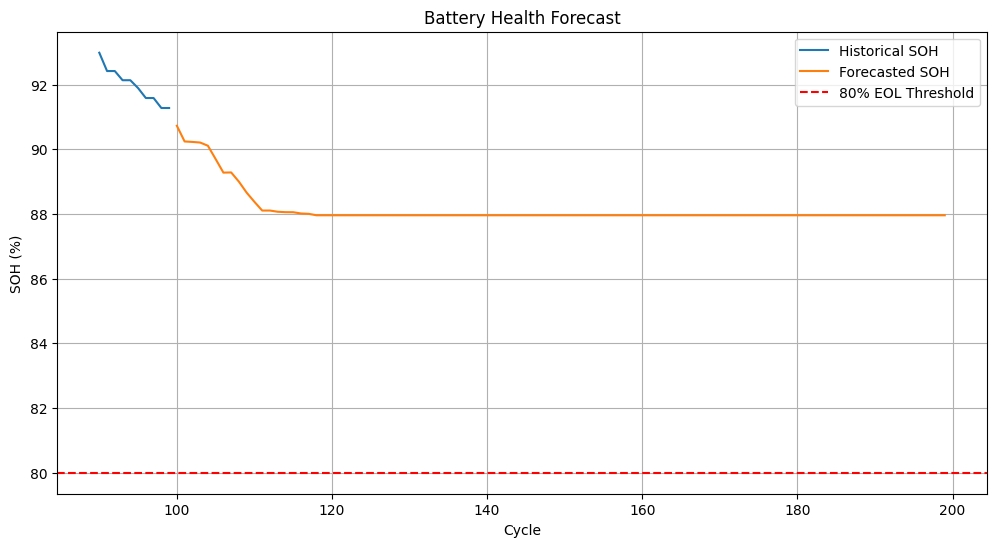

In [74]:
import matplotlib.pyplot as plt

current_soh = (
    battery_df["SOH"]
    .iloc[current_cycle-10:current_cycle]
    .values
)

plt.figure(figsize=(12,6))

plt.plot(
    range(current_cycle-10,
          current_cycle),
    current_soh,
    label="Historical SOH"
)

plt.plot(
    range(current_cycle,
          current_cycle + len(future_soh)),
    future_soh,
    label="Forecasted SOH"
)

plt.axhline(
    80,
    color="red",
    linestyle="--",
    label="80% EOL Threshold"
)

plt.xlabel("Cycle")
plt.ylabel("SOH (%)")

plt.title(
    "Battery Health Forecast"
)

plt.legend()
plt.grid(True)

plt.show()

In [75]:
print("Current SOH =", battery_df["SOH"].iloc[current_cycle])

print("Min Forecasted SOH =", future_soh.min())

print("Last Forecasted SOH =", future_soh[-1])

print("Forecast Length =", len(future_soh))

Current SOH = 90.75757205607074
Min Forecasted SOH = 87.96153811229966
Last Forecasted SOH = 87.96153811229966
Forecast Length = 100


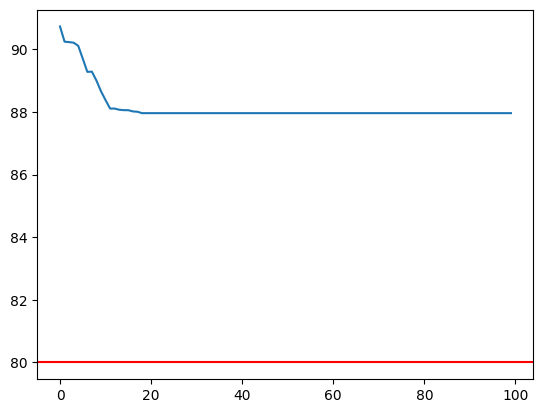

In [76]:
plt.plot(future_soh)
plt.axhline(80,color='red')
plt.show()

In [77]:
final_df["RUL"] = (
    final_df.groupby("Battery_ID")["Cycle"]
    .transform("max")
    - final_df["Cycle"]
)

final_df[
    ["Battery_ID","Cycle","SOH","RUL"]
].head()

,Battery_ID,Cycle,SOH,RUL
0,B0005,1,100.000000,167
1,B0005,1,100.000000,167
2,B0005,2,99.452721,166
3,B0005,2,99.452721,166
4,B0005,3,98.861386,165


In [79]:
FEATURES = [
    "SOH",
    "Capacity",
    "AvgVoltage",
    "AvgCurrent",
    "AvgTemp",
    "Re",
    "Rct"
]

TARGET = "RUL"

In [80]:
train_df = final_df[
    final_df["Battery_ID"].isin(
        ["B0005","B0006","B0007"]
    )
]

test_df = final_df[
    final_df["Battery_ID"] == "B0018"
]

In [81]:
X_train = train_df[FEATURES]
y_train = train_df["RUL"]

X_test = test_df[FEATURES]
y_test = test_df["RUL"]

In [82]:
from xgboost import XGBRegressor

rul_model = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

rul_model.fit(
    X_train,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [83]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

preds = rul_model.predict(X_test)

mae = mean_absolute_error(
    y_test,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

r2 = r2_score(
    y_test,
    preds
)

print("MAE =", mae)
print("RMSE =", rmse)
print("R² =", r2)

MAE = 15.774040222167969
RMSE = 18.31966783247413
R² = 0.7688502073287964


      Feature  Importance
1    Capacity    0.564111
0         SOH    0.224796
2  AvgVoltage    0.090534
3  AvgCurrent    0.055251
5          Re    0.039258
4     AvgTemp    0.019855
6         Rct    0.006194


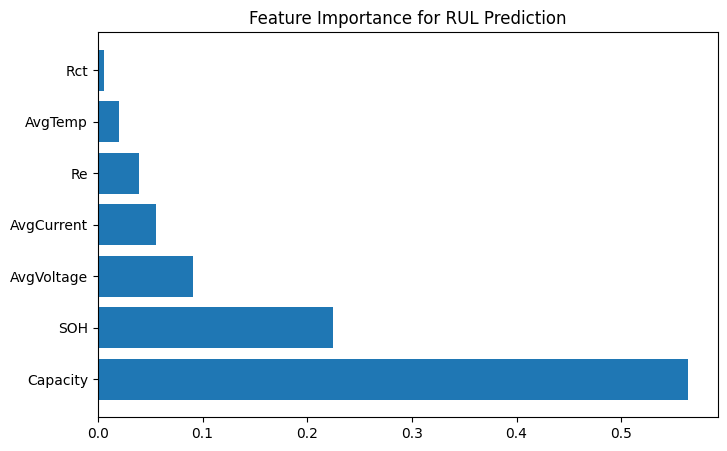

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": rul_model.feature_importances_
})

importance = (
    importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

print(importance)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "Feature Importance for RUL Prediction"
)

plt.show()

In [85]:
sample = test_df.iloc[-1]

predicted_rul = rul_model.predict(
    sample[FEATURES].values.reshape(1,-1)
)[0]

In [88]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(
    rul_model,
    "models/xgboost_rul.pkl"
)

['models/xgboost_rul.pkl']

In [91]:
from pathlib import Path

Path("data").mkdir(exist_ok=True)
final_df.to_csv("../data/final_df.csv", index=False)
